In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
train = pd.read_csv("data/train.csv")
stores = pd.read_csv("data/stores.csv")
holidays = pd.read_csv("data/holidays_events.csv")
oil = pd.read_csv("data/oil.csv")
transactions = pd.read_csv("data/transactions.csv")

print("Train Shape:", train.shape)
print("Stores Shape:", stores.shape)
print("Holidays Shape:", holidays.shape)
print("Oil Shape:", oil.shape)
print("Transactions Shape:", transactions.shape)


Train Shape: (3000888, 6)
Stores Shape: (54, 5)
Holidays Shape: (350, 6)
Oil Shape: (1218, 2)
Transactions Shape: (83488, 3)


In [2]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [4]:
train.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [5]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [6]:
train['date'] = pd.to_datetime(train['date'])

print("Start Date:", train['date'].min())
print("End Date:", train['date'].max())

Start Date: 2013-01-01 00:00:00
End Date: 2017-08-15 00:00:00


In [7]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()

daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


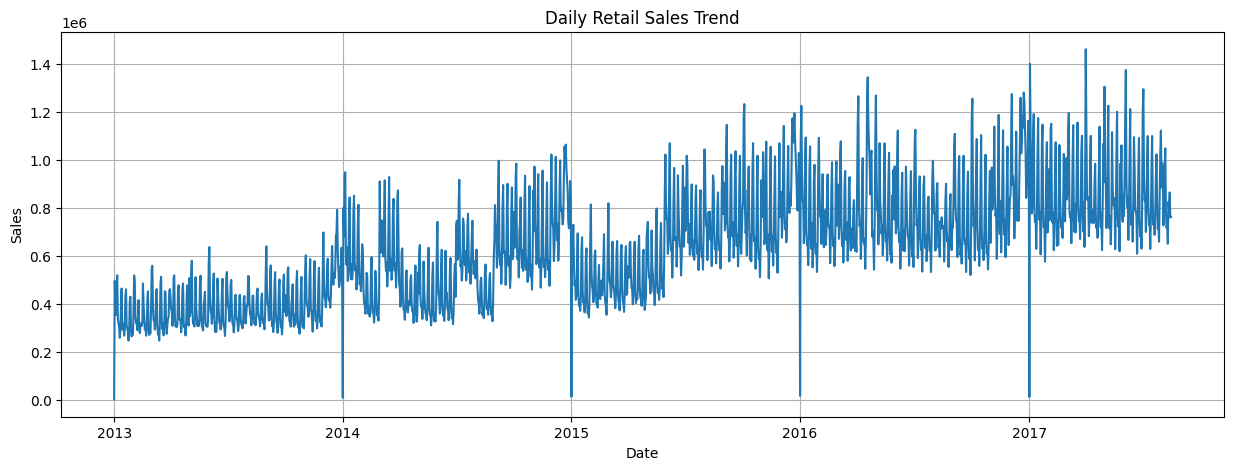

In [8]:
plt.figure(figsize=(15,5))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title("Daily Retail Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [9]:
print("Train")
print(train.isnull().sum())

print("\nStores")
print(stores.isnull().sum())

print("\nHolidays")
print(holidays.isnull().sum())

print("\nOil")
print(oil.isnull().sum())

print("\nTransactions")
print(transactions.isnull().sum())

Train
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Stores
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

Holidays
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

Oil
date           0
dcoilwtico    43
dtype: int64

Transactions
date            0
store_nbr       0
transactions    0
dtype: int64


In [10]:
daily_df = train.groupby('date').agg({
    'sales': 'sum',
    'onpromotion': 'sum'
}).reset_index()

daily_df.head()

,date,sales,onpromotion
0,2013-01-01,2511.618999,0
1,2013-01-02,496092.417944,0
2,2013-01-03,361461.231124,0
3,2013-01-04,354459.677093,0
4,2013-01-05,477350.121229,0


In [11]:
print(daily_df.shape)
daily_df.head()

(1684, 3)


,date,sales,onpromotion
0,2013-01-01,2511.618999,0
1,2013-01-02,496092.417944,0
2,2013-01-03,361461.231124,0
3,2013-01-04,354459.677093,0
4,2013-01-05,477350.121229,0


In [12]:
daily_transactions = transactions.groupby('date')['transactions'].sum().reset_index()

daily_transactions.head()

,date,transactions
0,2013-01-01,770
1,2013-01-02,93215
2,2013-01-03,78504
3,2013-01-04,78494
4,2013-01-05,93573


In [14]:
print(daily_df.dtypes)
print()
print(daily_transactions.dtypes)

date           datetime64[us]
sales                 float64
onpromotion             int64
dtype: object

date              str
transactions    int64
dtype: object


In [15]:
daily_transactions['date'] = pd.to_datetime(
    daily_transactions['date']
)

In [16]:
daily_df = daily_df.merge(
    daily_transactions,
    on='date',
    how='left'
)

In [17]:
print(daily_df.shape)
daily_df.head()

(1684, 4)


,date,sales,onpromotion,transactions
0,2013-01-01,2511.618999,0,770.0
1,2013-01-02,496092.417944,0,93215.0
2,2013-01-03,361461.231124,0,78504.0
3,2013-01-04,354459.677093,0,78494.0
4,2013-01-05,477350.121229,0,93573.0


In [22]:
oil.head()


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [21]:
oil.info()

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   str    
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), str(1)
memory usage: 19.2 KB


In [23]:
oil['date'] = pd.to_datetime(oil['date'])

In [24]:
oil.info()

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[us]
 1   dcoilwtico  1175 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 19.2 KB


In [25]:
oil['dcoilwtico'] = oil['dcoilwtico'].ffill()

In [26]:
oil.isnull().sum()

date          0
dcoilwtico    1
dtype: int64

In [27]:
oil['dcoilwtico'] = oil['dcoilwtico'].bfill()

In [28]:
oil.isnull().sum()


date          0
dcoilwtico    0
dtype: int64

In [29]:
daily_df = daily_df.merge(
    oil,
    on='date',
    how='left'
)

In [30]:
print(daily_df.shape)
daily_df.head()

(1684, 5)


,date,sales,onpromotion,transactions,dcoilwtico
0,2013-01-01,2511.618999,0,770.0,93.14
1,2013-01-02,496092.417944,0,93215.0,93.14
2,2013-01-03,361461.231124,0,78504.0,92.97
3,2013-01-04,354459.677093,0,78494.0,93.12
4,2013-01-05,477350.121229,0,93573.0,NaN


In [31]:
daily_df.isnull().sum()

date              0
sales             0
onpromotion       0
transactions      2
dcoilwtico      481
dtype: int64

In [32]:
print(daily_df.shape)
daily_df.isnull().sum()

(1684, 5)


date              0
sales             0
onpromotion       0
transactions      2
dcoilwtico      481
dtype: int64

In [33]:
daily_df['dcoilwtico'] = daily_df['dcoilwtico'].ffill()
daily_df['dcoilwtico'] = daily_df['dcoilwtico'].bfill()

In [34]:
daily_df['transactions'] = daily_df['transactions'].fillna(0)

In [35]:
daily_df.isnull().sum()

date            0
sales           0
onpromotion     0
transactions    0
dcoilwtico      0
dtype: int64

In [36]:
daily_df['year'] = daily_df['date'].dt.year
daily_df['month'] = daily_df['date'].dt.month
daily_df['day'] = daily_df['date'].dt.day
daily_df['dayofweek'] = daily_df['date'].dt.dayofweek

In [37]:
daily_df['is_weekend'] = (
    daily_df['dayofweek'] >= 5
).astype(int)

In [38]:
daily_df.head()

,date,sales,onpromotion,transactions,dcoilwtico,year,month,day,dayofweek,is_weekend
0,2013-01-01,2511.618999,0,770.0,93.14,2013,1,1,1,0
1,2013-01-02,496092.417944,0,93215.0,93.14,2013,1,2,2,0
2,2013-01-03,361461.231124,0,78504.0,92.97,2013,1,3,3,0
3,2013-01-04,354459.677093,0,78494.0,93.12,2013,1,4,4,0
4,2013-01-05,477350.121229,0,93573.0,93.12,2013,1,5,5,1


In [39]:
prophet_df = daily_df[['date', 'sales']].copy()

prophet_df.rename(
    columns={
        'date': 'ds',
        'sales': 'y'
    },
    inplace=True
)

prophet_df.head()

,ds,y
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [40]:
prophet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1684 entries, 0 to 1683
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1684 non-null   datetime64[us]
 1   y       1684 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 26.4 KB


In [41]:
train_data = prophet_df[:-90]
test_data = prophet_df[-90:]

print("Training Rows:", len(train_data))
print("Testing Rows:", len(test_data))

Training Rows: 1594
Testing Rows: 90


In [43]:
from prophet import Prophet

In [44]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [45]:
model.fit(train_data)

20:14:29 - cmdstanpy - INFO - Chain [1] start processing
20:14:29 - cmdstanpy - INFO - Chain [1] done processing


In [46]:
future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

In [47]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1679,2017-08-11,753274.355905,604113.613572,8.937931e+05
1680,2017-08-12,944801.715788,797153.458313,1.084634e+06
1681,2017-08-13,996880.912060,856348.490658,1.129652e+06
1682,2017-08-14,793881.381204,652370.121558,9.340476e+05
1683,2017-08-15,749053.604211,612873.727892,8.913988e+05


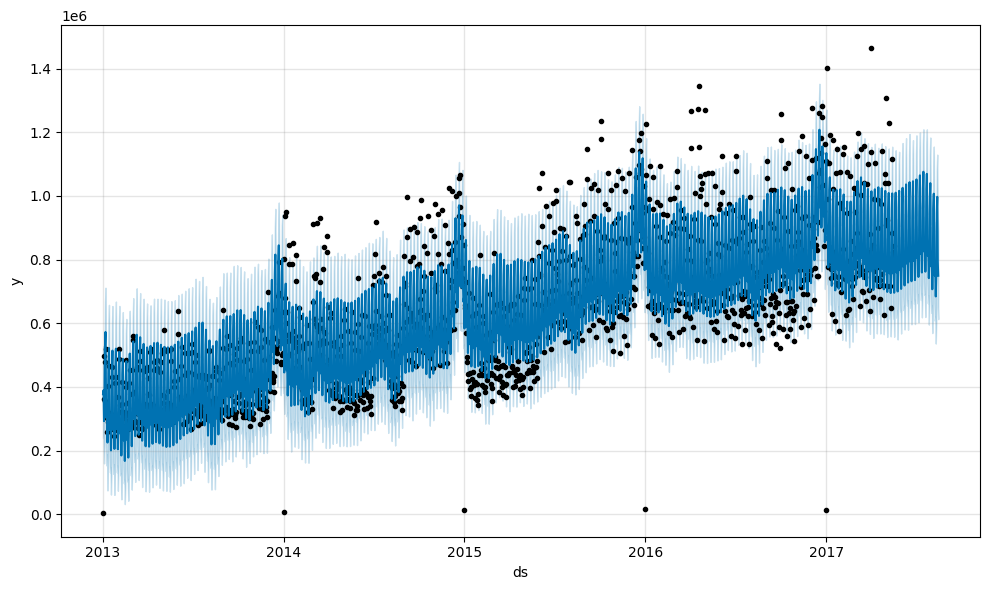

In [48]:
fig = model.plot(forecast)
plt.show()

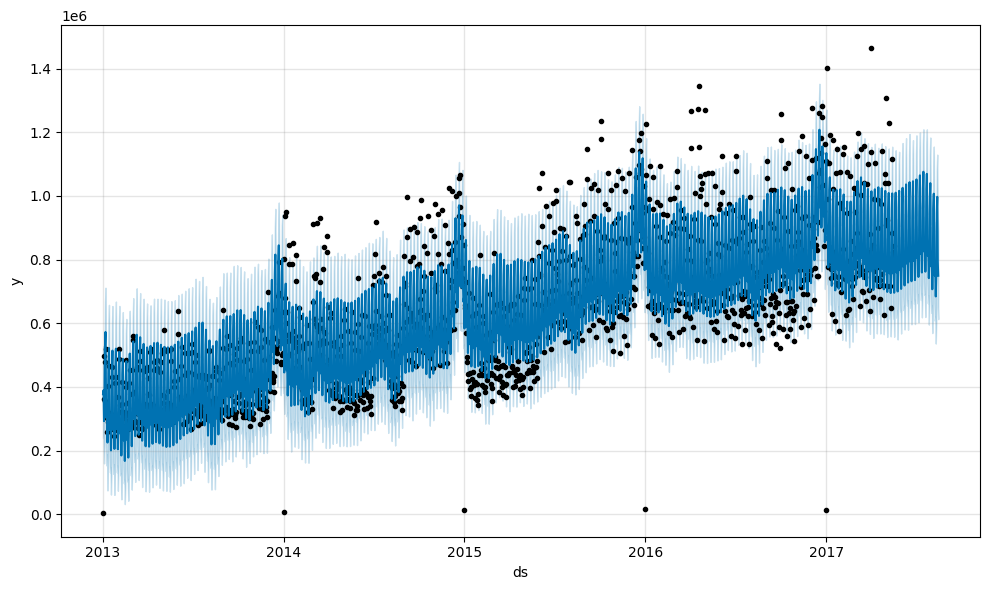

In [50]:
fig = model.plot(forecast)
plt.savefig("images/forecast_plot.png")
plt.show()

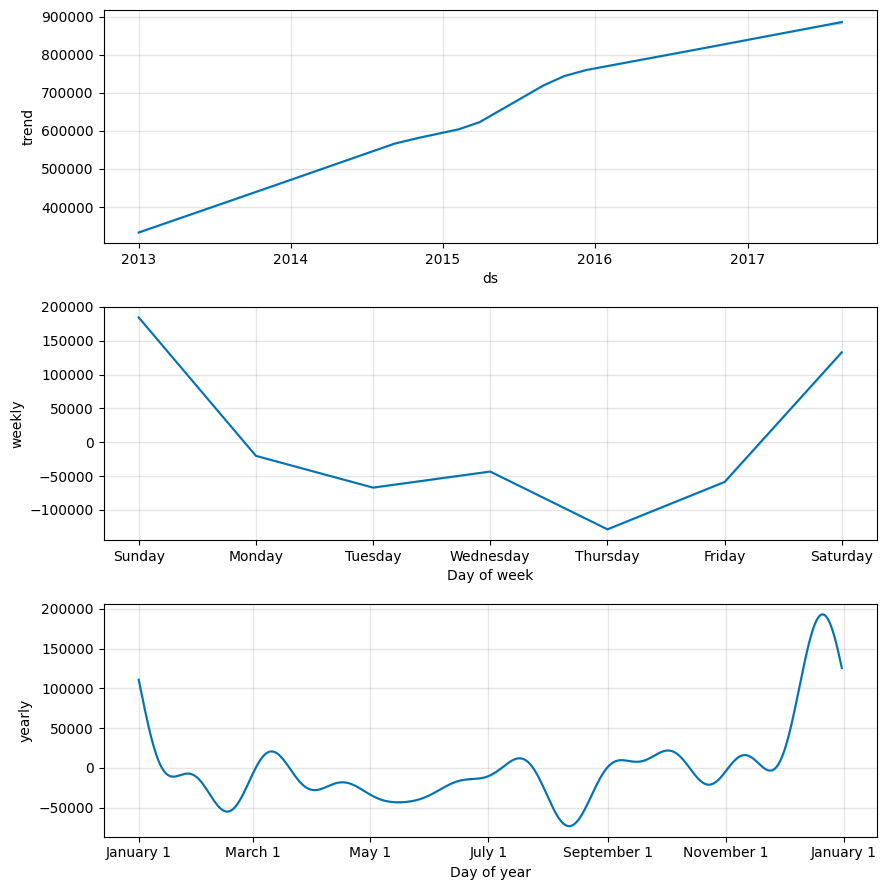

In [51]:
fig2 = model.plot_components(forecast)
plt.savefig("images/seasonality_components.png")
plt.show()

In [52]:
predictions = forecast[['ds', 'yhat']].tail(90)

predictions.reset_index(drop=True, inplace=True)
test_data.reset_index(drop=True, inplace=True)

In [53]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        test_data['y'],
        predictions['yhat']
    )
)

print("RMSE:", rmse)

RMSE: 94348.20191324118


In [57]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    test_data['y'],
    predictions['yhat']
)

print("MAPE (%):", mape * 100)

MAPE (%): 8.25643685039515


In [54]:
comparison = pd.DataFrame({
    'Date': test_data['ds'],
    'Actual Sales': test_data['y'],
    'Predicted Sales': predictions['yhat']
})

comparison.head(10)

,Date,Actual Sales,Predicted Sales
0,2017-05-18,6.284880e+05,6.957124e+05
1,2017-05-19,7.737754e+05,7.660608e+05
2,2017-05-20,1.035667e+06,9.580889e+05
3,2017-05-21,1.201939e+06,1.010004e+06
4,2017-05-22,7.789352e+05,8.061908e+05
5,2017-05-23,7.231518e+05,7.599278e+05
6,2017-05-24,7.463036e+05,7.843530e+05
7,2017-05-25,6.201082e+05,6.998334e+05
8,2017-05-26,9.845112e+05,7.706682e+05
9,2017-05-27,9.322199e+05,9.632062e+05


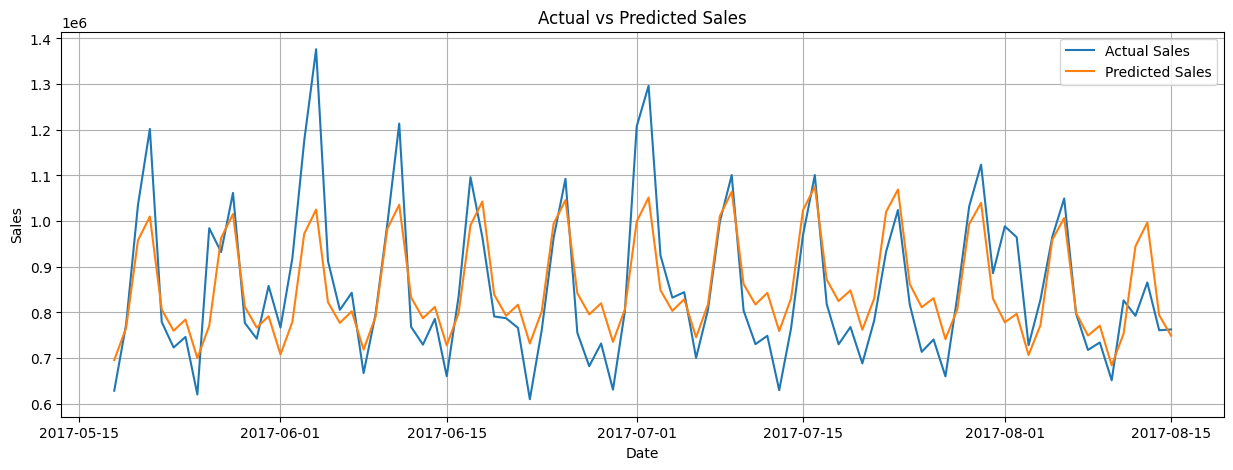

In [55]:
plt.figure(figsize=(15,5))

plt.plot(
    test_data['ds'],
    test_data['y'],
    label='Actual Sales'
)

plt.plot(
    predictions['ds'],
    predictions['yhat'],
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.show()

In [56]:
plt.savefig("images/actual_vs_predicted.png")

<Figure size 640x480 with 0 Axes>

In [58]:
daily_df.to_csv(
    "data/processed_sales_data.csv",
    index=False
)

In [59]:
comparison.to_csv(
    "data/predictions.csv",
    index=False
)

In [61]:
import pickle

with open("models/prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)